In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from seaborn import kdeplot
from ot.lp import wasserstein_1d as wd

plt.style.use("ggplot")

In [86]:
mcmc_4 = np.load("mcmc_results_4/avg_wd_mcmc.npy")
sample_no_list = np.load("sample_no_list.npy").tolist()

In [87]:
df_sde = pd.read_csv("wandb_export_2026-01-23T18_02_07.816-08_00.csv")
sde_mean = df_sde.iloc[:, 1].to_numpy()

In [88]:
no_trials = 10

ode_array = np.zeros((no_trials, 23))
for i in range(no_trials):
    ode_array[i, :] = np.load(f"converge_results_4/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mean = np.mean(ode_array, axis=0)

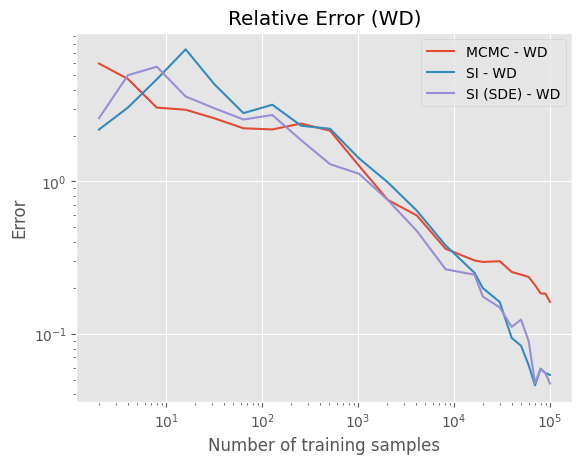

In [89]:
# plt.plot(sample_no_list, rel_swd_array, label="SWD")
plt.plot(sample_no_list, mcmc_4, label="MCMC - WD")
plt.plot(sample_no_list, ode_mean, label="SI - WD")
plt.plot(sample_no_list, sde_mean, label="SI (SDE) - WD")
# plt.plot(sample_no_list, 1 / np.sqrt(sample_no_list))
# plt.fill_between(sample_no_list, avg_wd_array - std_wd_array, avg_wd_array + std_wd_array, alpha=0.3)
# plt.fill_between(sample_no_list, si_mean - si_std, si_mean + si_std, alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of training samples")
plt.ylabel("Error")
plt.title("Relative Error (WD)")
plt.legend()

In [54]:
mcmc_samps = np.load("mcmc_results_4/mcmc_samps.npy")
mcmc_samps_flat = np.empty((10, 100000, 1))
for i in range(10):
    mcmc_samps_flat[i, :, :] = np.vstack(mcmc_samps[i, :, :, :])

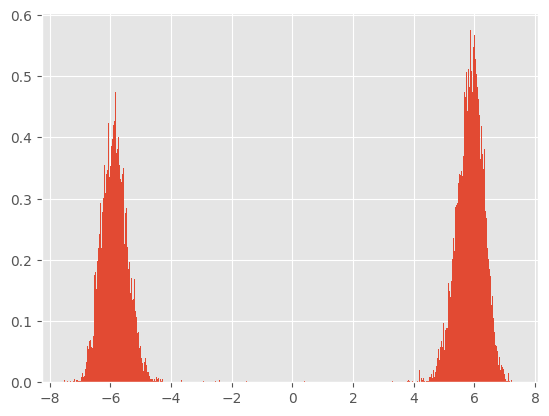

In [61]:
plt.hist(mcmc_samps_flat[0, :, :], bins = 1000, density=True);

<Axes: ylabel='Density'>

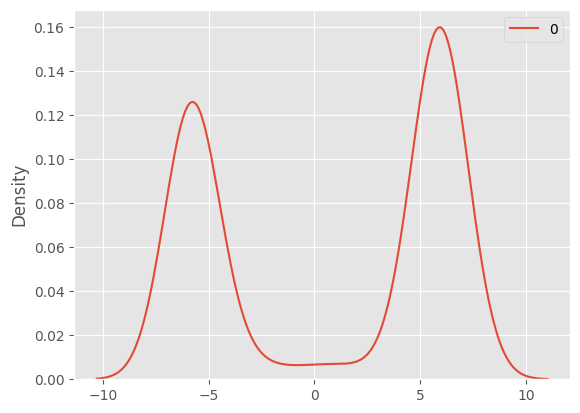

In [80]:
samp = mcmc_samps[0]
sample_no = 512 * 4
kdeplot(samp[:, : sample_no // 16, :].reshape(sample_no, 1))

In [83]:
rng = np.random.RandomState(1)
rej_samps = np.load("rej_samples_4.npy")[
    rng.choice(100000, size=(20000,)), :
]

In [95]:
samp = mcmc_samps[0]
sample_no = 512 * 128
wd(
    samp[:, : sample_no // 16, :].reshape(sample_no, ),
    rej_samps.reshape(-1),
    p=2
)

np.float64(6.964410224492431)

This shows that earlier on, the chain is actually closer to the target. The tailing off is actually a feature of the MCMC, not a bug

In [94]:
512 * 128

65536